# 06 — PySR Symbolic Regression

Goal:
- Train symbolic regression models for each 21 cm target parameter.
- Compare raw-scaled and log-scaled feature representations.
- Extract symbolic expressions, test performance, and complexity metrics.

Important:
This is an exploratory n=100 validation run, not the final production-scale symbolic regression analysis.

In [1]:
from pathlib import Path
import json
import time
import traceback
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error

from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"
LOGS = PROJECT_ROOT / "logs"

for path in [DATA_PROCESSED, RESULTS, FIGURES, LOGS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_PROCESSED)
print("Results:", RESULTS)
print("Figures:", FIGURES)
print("Logs:", LOGS)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Processed data: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed
Results: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results
Figures: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures
Logs: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/logs


In [3]:
DATA_TAG = "n2000_production"
RANDOM_SEED = 42

# Start lightweight. Increase later only after this works.
NITERATIONS = 200
POPULATIONS = 15
MAXSIZE = 20

FEATURE_REPRESENTATIONS = ["raw_scaled", "log_scaled"]

print("Data tag:", DATA_TAG)
print("PySR iterations:", NITERATIONS)
print("Populations:", POPULATIONS)
print("Max expression size:", MAXSIZE)
print("Feature representations:", FEATURE_REPRESENTATIONS)

Data tag: n2000_production
PySR iterations: 200
Populations: 15
Max expression size: 20
Feature representations: ['raw_scaled', 'log_scaled']


In [4]:
X_train_scaled_path = DATA_PROCESSED / f"X_train_scaled_{DATA_TAG}.npy"
X_test_scaled_path = DATA_PROCESSED / f"X_test_scaled_{DATA_TAG}.npy"

X_train_log_scaled_path = DATA_PROCESSED / f"X_train_log_scaled_{DATA_TAG}.npy"
X_test_log_scaled_path = DATA_PROCESSED / f"X_test_log_scaled_{DATA_TAG}.npy"

y_train_raw_path = DATA_PROCESSED / f"y_train_raw_{DATA_TAG}.npy"
y_test_raw_path = DATA_PROCESSED / f"y_test_raw_{DATA_TAG}.npy"

feature_names_path = DATA_PROCESSED / f"feature_names_{DATA_TAG}.csv"
target_names_path = DATA_PROCESSED / f"target_names_{DATA_TAG}.csv"

In [5]:
X_train_scaled = np.load(X_train_scaled_path)
X_test_scaled = np.load(X_test_scaled_path)

X_train_log_scaled = np.load(X_train_log_scaled_path)
X_test_log_scaled = np.load(X_test_log_scaled_path)

y_train_raw = np.load(y_train_raw_path)
y_test_raw = np.load(y_test_raw_path)

feature_names_df = pd.read_csv(feature_names_path)
target_names_df = pd.read_csv(target_names_path)

feature_names = feature_names_df["feature_name"].tolist()
target_names = target_names_df["target_name"].tolist()

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_train_log_scaled:", X_train_log_scaled.shape)
print("X_test_log_scaled:", X_test_log_scaled.shape)

print("y_train_raw:", y_train_raw.shape)
print("y_test_raw:", y_test_raw.shape)

print("Targets:", target_names)

X_train_scaled: (1600, 57)
X_test_scaled: (400, 57)
X_train_log_scaled: (1600, 57)
X_test_log_scaled: (400, 57)
y_train_raw: (1600, 5)
y_test_raw: (400, 5)
Targets: ['zeta', 'log10_Tvir', 'R_mfp', 'log10_LX', 'sigma8']


In [6]:
assert X_train_scaled.shape == X_train_log_scaled.shape
assert X_test_scaled.shape == X_test_log_scaled.shape

assert X_train_scaled.shape[1] == len(feature_names)
assert y_train_raw.shape[1] == len(target_names)

assert np.all(np.isfinite(X_train_scaled))
assert np.all(np.isfinite(X_test_scaled))
assert np.all(np.isfinite(X_train_log_scaled))
assert np.all(np.isfinite(X_test_log_scaled))
assert np.all(np.isfinite(y_train_raw))
assert np.all(np.isfinite(y_test_raw))

print("PySR input validation passed.")

PySR input validation passed.


In [7]:
feature_sets = {
    "raw_scaled": {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
    },
    "log_scaled": {
        "X_train": X_train_log_scaled,
        "X_test": X_test_log_scaled,
    },
}

In [8]:
def make_pysr_model(output_dir, target_name, feature_representation):
    """
    Create a lightweight PySRRegressor for the first n=100 validation run.
    Uses only built-in PySR operators for maximum compatibility.
    """

    model = PySRRegressor(
        niterations=NITERATIONS,
        populations=POPULATIONS,
        maxsize=MAXSIZE,

        binary_operators=["+", "-", "*", "/"],
        unary_operators=[
            "sqrt",
            "log",
        ],

        model_selection="best",
        elementwise_loss="loss(x, y) = (x - y)^2",

        random_state=RANDOM_SEED,
        deterministic=True,
        parallelism="serial",

        verbosity=1,
        progress=False,

        temp_equation_file=False,
        output_directory=str(output_dir),
    )

    return model

In [9]:
def evaluate_single_target(y_true, y_pred, target_name, feature_representation, equation, complexity):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    return {
        "target": target_name,
        "feature_representation": feature_representation,
        "r2": r2,
        "mae": mae,
        "equation": equation,
        "complexity": complexity,
    }

In [10]:
target_name = "sigma8"
target_index = target_names.index(target_name)
feature_representation = "log_scaled"

Xtr = feature_sets[feature_representation]["X_train"]
Xte = feature_sets[feature_representation]["X_test"]

ytr = y_train_raw[:, target_index]
yte = y_test_raw[:, target_index]

test_output_dir = RESULTS / "pysr_test_sigma8_log_scaled"
test_output_dir.mkdir(parents=True, exist_ok=True)

test_model = make_pysr_model(
    output_dir=test_output_dir,
    target_name=target_name,
    feature_representation=feature_representation,
)

start = time.time()

test_model.fit(
    Xtr,
    ytr,
    variable_names=[f"x{i}" for i in range(Xtr.shape[1])]
)

elapsed = time.time() - start

test_pred = test_model.predict(Xte)
test_equation = str(test_model.sympy())

print("Elapsed time [s]:", elapsed)
print("Test R2:", r2_score(yte, test_pred))
print("Test MAE:", mean_absolute_error(yte, test_pred))
print("Equation:")
print(test_equation)

Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 8.950e+04
Progress: 504 / 3000 total iterations (16.800%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.875e-03  0.000e+00  y = 0.82481
5           4.037e-05  9.595e-01  y = (x17 * 0.042831) + 0.82481
9           2.854e-05  8.675e-02  y = 0.76457 / ((0.50199 / (-10.268 / x17)) + 0.92951)
11          2.846e-05  1.414e-03  y = (0.90097 / ((2.2083 / (-37.366 / x17)) + 1.1107)) - -0...
                                      .011345
12          2.589e-05  9.451e-02  y = sqrt(0.46284 / ((1.3507 / (-48.516 / (x17 / 0.38605)))...
                                       + 0.68595))
14          2.530e-05  1.153e-02  y = 0.7014 / sqrt((0.56055 / ((-30.045 / (x17 / 0.2433)) -...
                                       -0.13655)) + 0.73033)
15          2.506e

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 8.880e+04
Progress: 1087 / 3000 total iterations (36.233%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.875e-03  0.000e+00  y = 0.82481
5           4.037e-05  9.595e-01  y = (x17 * 0.042831) + 0.82481
7           2.678e-05  2.052e-01  y = (-2.4713 / (x16 + -7.6088)) - -0.4944
8           2.606e-05  2.734e-02  y = sqrt(0.55358 / ((x17 * -0.085492) + 0.82034))
9           2.525e-05  3.177e-02  y = (-0.70275 / ((-16.306 / x17) + 1.5931)) - -0.82062
13          2.487e-05  3.765e-03  y = (-0.71447 / ((x11 / -7.0088) + ((-16.306 / x17) + 1.51...
                                      98))) - -0.82079
15          2.431e-05  1.148e-02  y = (-0.71046 / ((-16.306 / x17) + (((x0 + x17) * -0.21798...
                                      ) + 1.5647))) - -

In [11]:
all_results = []
all_predictions = {}
failed_runs = []

start_all = time.time()

for feature_representation in FEATURE_REPRESENTATIONS:

    Xtr = feature_sets[feature_representation]["X_train"]
    Xte = feature_sets[feature_representation]["X_test"]

    for target_index, target_name in enumerate(target_names):

        print("=" * 80)
        print(f"Training PySR | target={target_name} | features={feature_representation}")
        print("=" * 80)

        ytr = y_train_raw[:, target_index]
        yte = y_test_raw[:, target_index]

        output_dir = RESULTS / f"pysr_{target_name}_{feature_representation}_{DATA_TAG}"
        output_dir.mkdir(parents=True, exist_ok=True)

        try:
            model = make_pysr_model(
                output_dir=output_dir,
                target_name=target_name,
                feature_representation=feature_representation,
            )

            start = time.time()

            model.fit(
                Xtr,
                ytr,
                variable_names=[f"x{i}" for i in range(Xtr.shape[1])]
            )

            elapsed = time.time() - start

            y_pred = model.predict(Xte)

            equations_df = model.equations_.copy()
            best_equation = str(model.sympy())

            if "complexity" in equations_df.columns:
                best_complexity = int(
                    equations_df.loc[equations_df["score"].idxmax(), "complexity"]
                )
            else:
                best_complexity = np.nan

            result = evaluate_single_target(
                y_true=yte,
                y_pred=y_pred,
                target_name=target_name,
                feature_representation=feature_representation,
                equation=best_equation,
                complexity=best_complexity,
            )

            result["elapsed_time_seconds"] = elapsed
            result["n_equations"] = len(equations_df)

            all_results.append(result)

            all_predictions[(target_name, feature_representation)] = y_pred

            equations_path = RESULTS / f"pysr_equations_{target_name}_{feature_representation}_{DATA_TAG}.csv"
            equations_df.to_csv(equations_path, index=False)

            model_path = RESULTS / f"pysr_model_{target_name}_{feature_representation}_{DATA_TAG}.joblib"
            joblib.dump(model, model_path)

            print("Success.")
            print("R2:", result["r2"])
            print("MAE:", result["mae"])
            print("Complexity:", result["complexity"])
            print("Equation:", result["equation"])

        except Exception as e:
            print("FAILED.")
            print("Error:", repr(e))

            failed_runs.append({
                "target": target_name,
                "feature_representation": feature_representation,
                "error": repr(e),
                "traceback": traceback.format_exc(),
            })

elapsed_all = time.time() - start_all

print("=" * 80)
print("All PySR runs finished.")
print("Elapsed time [s]:", elapsed_all)
print("Successful runs:", len(all_results))
print("Failed runs:", len(failed_runs))

Training PySR | target=zeta | features=raw_scaled


[ Info: Started!



Expressions evaluated per second: 6.730e+04
Progress: 355 / 3000 total iterations (11.833%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.060e+02  0.000e+00  y = 45.23
3           4.053e+02  8.147e-04  y = x1 + 45.233
5           4.045e+02  9.698e-04  y = (x1 - -45.596) + x20
7           4.041e+02  4.824e-04  y = ((x3 * x1) + -1.0389) - -45.243
8           4.038e+02  7.197e-04  y = log(x20 - -1.0389) + (x1 - -45.596)
9           4.036e+02  5.692e-04  y = (x1 * x3) + (x0 + (-1.0389 - -45.754))
10          4.030e+02  1.448e-03  y = (x3 * x1) + (log(x20 - -1.0389) - -45.754)
12          4.020e+02  1.260e-03  y = (x3 * x1) + (x0 + (log(x20 - -1.0389) - -45.754))
14          4.017e+02  2.690e-04  y = ((x1 * x3) + (x0 + (log(x20 - -1.0389) - -45.754))) + ...
                        

[ Info: Final population:
[ Info: Results saved to:


Success.
R2: -0.0008636127355212686
MAE: 17.797696235899835
Complexity: 5
Equation: x1*x3 + 44.843826
Training PySR | target=log10_Tvir | features=raw_scaled
  - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_zeta_raw_scaled_n2000_production/20260518_123214_lklVjS/hall_of_fame.csv


...

  - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_R_mfp_log_scaled_n2000_production/20260518_123551_0nz0XR/hall_of_fame.csv

Expressions evaluated per second: 8.370e+04
Progress: 500 / 3000 total iterations (16.667%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.336e+00  0.000e+00  y = 39.975
4           1.335e+00  3.470e-04  y = sqrt(x6 - -1598)
5           1.332e+00  1.865e-03  y = (x42 * -0.062284) + 39.975
6           1.332e+00  7.010e-05  y = sqrt((-0.23245 / x56) + 1598.3)
8           1.331e+00  4.200e-04  y = sqrt((-0.23245 / x56) - (-1596.8 - x6))
9           1.328e+00  2.367e-03  y = (x51 / (-27.126 - (x12 / x2))) + 39.974
11          1.328e+00  1.717e-05  y = (x51 / (-25.851 - ((x12 + 0.25501) / x44))) + 39.974
13          1.327e+00  2.719e-04

[ Info: Started!



Expressions evaluated per second: 8.640e+04
Progress: 997 / 3000 total iterations (33.233%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.336e+00  0.000e+00  y = 39.975
4           1.335e+00  3.470e-04  y = sqrt(x6 - -1598)
5           1.332e+00  2.151e-03  y = (x43 * -0.06527) + 39.975
7           1.332e+00  3.332e-05  y = 39.975 - (x43 / (15.076 - x31))
8           1.331e+00  5.569e-04  y = sqrt((-0.23245 / x56) - (-1596.8 - x6))
9           1.328e+00  2.367e-03  y = (x51 / (-27.126 - (x12 / x2))) + 39.974
11          1.327e+00  2.856e-04  y = 39.974 + (x51 / ((-27.126 - (x12 / x2)) / 1.3958))
13          1.325e+00  9.998e-04  y = (x51 / (-27.126 - ((x12 / x2) - (-0.81367 / x19)))) + ...
                                      39.974
18          1.325e+00  1.725e-05  y = (x51 

[ Info: Final population:
[ Info: Results saved to:
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


  - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_log10_LX_log_scaled_n2000_production/20260518_123626_lUw8zB/hall_of_fame.csv

Expressions evaluated per second: 9.000e+04
Progress: 524 / 3000 total iterations (17.467%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.875e-03  0.000e+00  y = 0.82481
5           4.037e-05  9.595e-01  y = (x17 * 0.042831) + 0.82481
9           2.529e-05  1.169e-01  y = (-0.70351 / ((-16.306 / x17) + 1.5198)) - -0.82081
15          2.506e-05  1.530e-03  y = (-0.70955 / ((-16.306 / x17) + (1.5196 - (-2.296 / (-2...
                                      9.443 / x17))))) - -0.8208
18          2.455e-05  6.854e-03  y = sqrt(0.55443 / ((1.3472 / (-48.516 / ((x17 / 0.32121) ...
                                      - ((x16 - x17) /

In [12]:
pysr_results = pd.DataFrame(all_results)

pysr_results

,target,feature_representation,r2,mae,equation,complexity,elapsed_time_seconds,n_equations
0,zeta,raw_scaled,-0.000864,17.797696,x1*x3 + 44.843826,5,36.179843,13
1,log10_Tvir,raw_scaled,-3.769421,0.428326,4.748392 + 0.030820062/(x26/0.051543973 + 0.17...,9,25.611980,8
2,R_mfp,raw_scaled,0.463976,4.270769,(-x17 - x51 + 1.3601621)/0.077864446,7,31.313583,10
3,log10_LX,raw_scaled,-0.075527,1.018850,sqrt(1598.5477 + x47/x33),6,31.550347,11
4,sigma8,raw_scaled,0.985074,0.004160,x16*0.04298514 + 0.8248071,5,29.817344,8
5,zeta,log_scaled,-0.001027,17.784315,x1*x3 - 1*(-44.631496),5,31.841353,9
6,log10_Tvir,log_scaled,-0.018168,0.378551,4.7448277 - (-0.28816974)*x24*x24*(x13 - x14),11,29.772277,13
7,R_mfp,log_scaled,0.450504,4.381260,(x38 - (x12 + x46))*3.6185212 - 1*(-17.534563),9,35.490247,11
8,log10_LX,log_scaled,-0.032971,1.007129,sqrt(1597.8392 + 0.4432827/(x38 + 0.4896771)),8,29.253336,13
9,sigma8,log_scaled,0.985885,0.004100,2.53717309224262*sqrt(-1/(x16 - 9.539534)),5,27.245059,9


In [19]:
best_pysr = (
    pysr_results
    .sort_values("r2", ascending=False)
    .groupby("target")
    .head(1)
    .sort_values("r2", ascending=False)
)

best_pysr

,target,feature_representation,r2,mae,equation,complexity,elapsed_time_seconds,n_equations
4,sigma8,raw_scaled,0.981022,0.005626,sqrt(0.0682763*x15 + 0.68826646),5,2.106970,12
3,log10_LX,raw_scaled,0.132253,0.908207,x12 - x25 + 40.032467,5,2.130874,11
2,R_mfp,raw_scaled,0.019634,4.777402,(1.4850445 - (x18 + x54))*(x41 + 11.34017),9,2.217467,13
1,log10_Tvir,raw_scaled,-0.020773,0.395024,log(-2.5181272*x3/x48 + 116.42029),8,2.223027,12
0,zeta,raw_scaled,-0.122861,16.194056,32.542965*log(-x4*(-x8 - 0.5816575) + 4.0228972),10,2.619826,12


In [20]:
pysr_results_path = RESULTS / f"pysr_results_{DATA_TAG}.csv"
best_pysr_path = RESULTS / f"pysr_best_results_{DATA_TAG}.csv"

pysr_results.to_csv(pysr_results_path, index=False)
best_pysr.to_csv(best_pysr_path, index=False)

print("Saved PySR results:")
print(" -", pysr_results_path)
print(" -", best_pysr_path)

Saved PySR results:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_best_results_n100_validation.csv


In [21]:
baseline_results_path = RESULTS / f"baseline_results_{DATA_TAG}.csv"
baseline_results = pd.read_csv(baseline_results_path)

baseline_best = (
    baseline_results
    .sort_values("r2", ascending=False)
    .groupby("target")
    .head(1)
    .sort_values("r2", ascending=False)
)

baseline_best

,model,feature_representation,target,r2,mae
14,MLP,raw_scaled,sigma8,0.960441,0.007485
17,MLP,log_scaled,R_mfp,0.175866,4.734829
1,Random Forest,raw_scaled,log10_Tvir,0.047715,0.384969
8,Random Forest,log_scaled,log10_LX,-0.063462,0.985332
5,Random Forest,log_scaled,zeta,-0.181410,16.362191


In [22]:
comparison_df = best_pysr[[
    "target",
    "r2",
    "mae",
    "feature_representation",
    "complexity",
    "equation",
]].rename(columns={
    "r2": "pysr_best_r2",
    "mae": "pysr_best_mae",
    "feature_representation": "pysr_feature_representation",
    "complexity": "pysr_complexity",
    "equation": "pysr_equation",
})

baseline_comp = baseline_best[[
    "target",
    "model",
    "feature_representation",
    "r2",
    "mae",
]].rename(columns={
    "model": "baseline_model",
    "feature_representation": "baseline_feature_representation",
    "r2": "baseline_best_r2",
    "mae": "baseline_best_mae",
})

comparison_df = comparison_df.merge(
    baseline_comp,
    on="target",
    how="left",
)

comparison_df["r2_gap_pysr_minus_baseline"] = (
    comparison_df["pysr_best_r2"] - comparison_df["baseline_best_r2"]
)

comparison_df

,target,pysr_best_r2,pysr_best_mae,pysr_feature_representation,pysr_complexity,pysr_equation,baseline_model,baseline_feature_representation,baseline_best_r2,baseline_best_mae,r2_gap_pysr_minus_baseline
0,sigma8,0.981022,0.005626,raw_scaled,5,sqrt(0.0682763*x15 + 0.68826646),MLP,raw_scaled,0.960441,0.007485,0.020581
1,log10_LX,0.132253,0.908207,raw_scaled,5,x12 - x25 + 40.032467,Random Forest,log_scaled,-0.063462,0.985332,0.195715
2,R_mfp,0.019634,4.777402,raw_scaled,9,(1.4850445 - (x18 + x54))*(x41 + 11.34017),MLP,log_scaled,0.175866,4.734829,-0.156232
3,log10_Tvir,-0.020773,0.395024,raw_scaled,8,log(-2.5181272*x3/x48 + 116.42029),Random Forest,raw_scaled,0.047715,0.384969,-0.068489
4,zeta,-0.122861,16.194056,raw_scaled,10,32.542965*log(-x4*(-x8 - 0.5816575) + 4.0228972),Random Forest,log_scaled,-0.181410,16.362191,0.058549


In [23]:
comparison_path = RESULTS / f"pysr_vs_baseline_comparison_{DATA_TAG}.csv"

comparison_df.to_csv(comparison_path, index=False)

print("Saved comparison to:", comparison_path)

Saved comparison to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_vs_baseline_comparison_n100_validation.csv


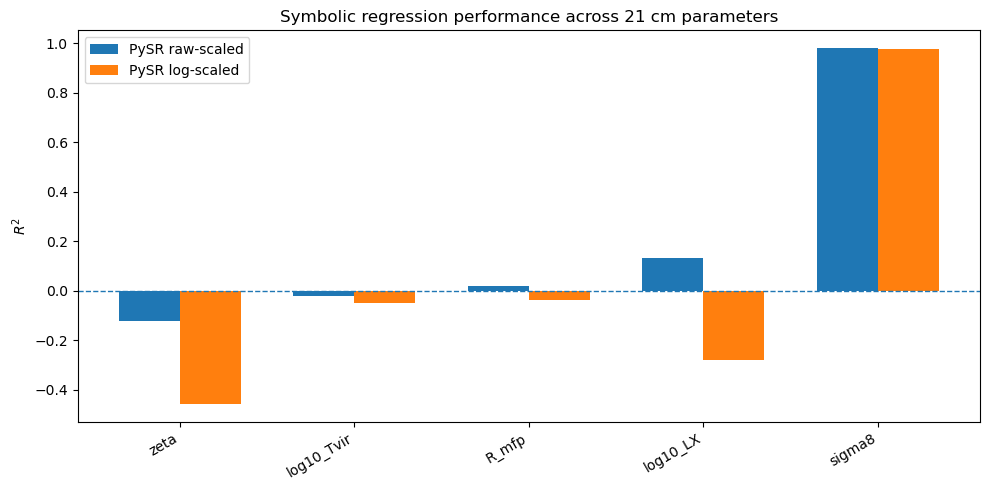

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/pysr_r2_comparison_n100_validation.png


In [24]:
plt.figure(figsize=(10, 5))

x = np.arange(len(target_names))
width = 0.35

raw_values = []
log_values = []

for target in target_names:
    sub_raw = pysr_results[
        (pysr_results["target"] == target)
        & (pysr_results["feature_representation"] == "raw_scaled")
    ]
    sub_log = pysr_results[
        (pysr_results["target"] == target)
        & (pysr_results["feature_representation"] == "log_scaled")
    ]

    raw_values.append(sub_raw["r2"].values[0] if len(sub_raw) else np.nan)
    log_values.append(sub_log["r2"].values[0] if len(sub_log) else np.nan)

plt.bar(x - width / 2, raw_values, width=width, label="PySR raw-scaled")
plt.bar(x + width / 2, log_values, width=width, label="PySR log-scaled")

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, target_names, rotation=30, ha="right")
plt.ylabel(r"$R^2$")
plt.title("Symbolic regression performance across 21 cm parameters")
plt.legend()
plt.tight_layout()

pysr_r2_fig_path = FIGURES / f"pysr_r2_comparison_{DATA_TAG}.png"
plt.savefig(pysr_r2_fig_path, dpi=300)
plt.show()

print("Saved figure to:", pysr_r2_fig_path)

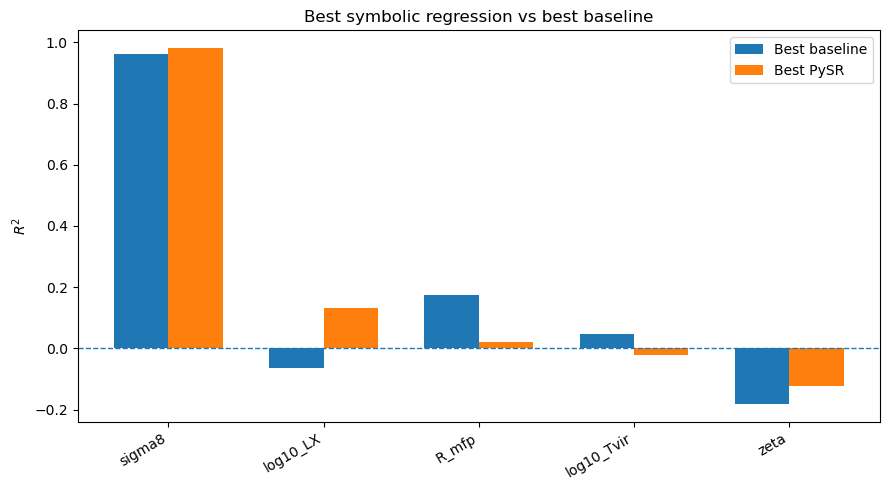

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/pysr_vs_baseline_r2_n100_validation.png


In [25]:
plt.figure(figsize=(9, 5))

plot_targets = comparison_df["target"].tolist()
x = np.arange(len(plot_targets))
width = 0.35

plt.bar(
    x - width / 2,
    comparison_df["baseline_best_r2"],
    width=width,
    label="Best baseline",
)

plt.bar(
    x + width / 2,
    comparison_df["pysr_best_r2"],
    width=width,
    label="Best PySR",
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, plot_targets, rotation=30, ha="right")
plt.ylabel(r"$R^2$")
plt.title("Best symbolic regression vs best baseline")
plt.legend()
plt.tight_layout()

comparison_fig_path = FIGURES / f"pysr_vs_baseline_r2_{DATA_TAG}.png"
plt.savefig(comparison_fig_path, dpi=300)
plt.show()

print("Saved figure to:", comparison_fig_path)

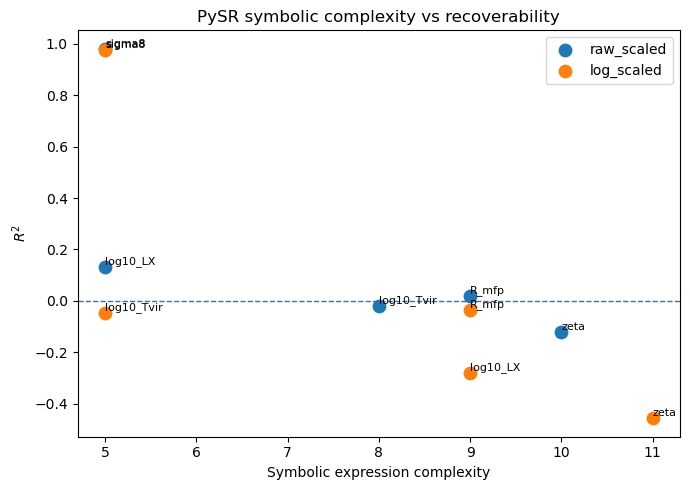

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/pysr_complexity_vs_r2_n100_validation.png


In [26]:
plt.figure(figsize=(7, 5))

for feature_representation in FEATURE_REPRESENTATIONS:
    sub = pysr_results[pysr_results["feature_representation"] == feature_representation]

    plt.scatter(
        sub["complexity"],
        sub["r2"],
        s=80,
        label=feature_representation,
    )

    for _, row in sub.iterrows():
        plt.text(
            row["complexity"],
            row["r2"],
            row["target"],
            fontsize=8,
            ha="left",
            va="bottom",
        )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel("Symbolic expression complexity")
plt.ylabel(r"$R^2$")
plt.title("PySR symbolic complexity vs recoverability")
plt.legend()
plt.tight_layout()

complexity_fig_path = FIGURES / f"pysr_complexity_vs_r2_{DATA_TAG}.png"
plt.savefig(complexity_fig_path, dpi=300)
plt.show()

print("Saved figure to:", complexity_fig_path)

In [27]:
pysr_metadata = {
    "notebook": "06_pysr_symbolic_regression.ipynb",
    "data_tag": DATA_TAG,
    "n_train": int(X_train_scaled.shape[0]),
    "n_test": int(X_test_scaled.shape[0]),
    "n_features": int(X_train_scaled.shape[1]),
    "n_targets": int(y_train_raw.shape[1]),
    "target_names": target_names,
    "feature_representations": FEATURE_REPRESENTATIONS,
    "pysr_settings": {
        "niterations": NITERATIONS,
        "populations": POPULATIONS,
        "maxsize": MAXSIZE,
        "binary_operators": ["+", "-", "*", "/"],
        "unary_operators": ["sqrt", "log"],
        "model_selection": "best",
        "random_state": RANDOM_SEED,
        "deterministic": True,
        "parallelism": "serial",
    },
    "elapsed_time_seconds": elapsed_all,
    "failed_runs": failed_runs,
    "notes": (
        "Initial symbolic regression validation run on n=100 simulations. "
        "Results should be interpreted as exploratory and used to guide "
        "larger production-scale runs."
    ),
}

pysr_metadata_path = RESULTS / f"pysr_metadata_{DATA_TAG}.json"

with open(pysr_metadata_path, "w") as f:
    json.dump(pysr_metadata, f, indent=2)

print("Saved PySR metadata to:", pysr_metadata_path)

Saved PySR metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_metadata_n100_validation.json


In [28]:
print("=" * 60)
print("Notebook 06 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)
print("Successful PySR runs:", len(pysr_results))
print("Failed PySR runs:", len(failed_runs))

print("\nBest PySR results:")
print(best_pysr[["target", "feature_representation", "r2", "mae", "complexity"]])

print("\nSaved files:")
print(" -", pysr_results_path)
print(" -", best_pysr_path)
print(" -", comparison_path)
print(" -", pysr_r2_fig_path)
print(" -", comparison_fig_path)
print(" -", complexity_fig_path)
print(" -", pysr_metadata_path)

Notebook 06 completed successfully.
Dataset tag: n100_validation
Successful PySR runs: 10
Failed PySR runs: 0

Best PySR results:
       target feature_representation        r2        mae  complexity
4      sigma8             raw_scaled  0.981022   0.005626           5
3    log10_LX             raw_scaled  0.132253   0.908207           5
2       R_mfp             raw_scaled  0.019634   4.777402           9
1  log10_Tvir             raw_scaled -0.020773   0.395024           8
0        zeta             raw_scaled -0.122861  16.194056          10

Saved files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_best_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/pysr_vs_baseline_comparison_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/pysr_r2_comparison_n100_validation.png
 -